In [63]:
# Импортируем библиотеки
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
import math
import warnings
import datetime
from datetime import date, timedelta, time
import requests
from bs4 import BeautifulSoup
from time import sleep
import random
import string
import nltk
from scipy import stats as st 
from scipy.stats import shapiro, ttest_ind, levene
from IPython.display import Markdown
from nltk.corpus import stopwords
import re
from wordcloud import WordCloud
from collections import Counter

# Настройки
pd.set_option('display.max_columns', None) 
pd.options.display.float_format = '{:,.2f}'.format
warnings.filterwarnings('ignore')

# Загрузка стоп-слов
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/uliana/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Загрузка данных

In [64]:
# Загружаем данные
df = pd.read_csv('dataset.txt', delimiter='\t', header=None, names=['col'])
df[['label', 'comment']] = df['col'].str.split(n=1, expand=True)
df = df.drop('col', axis=1)
display(df.head())

,label,comment
0,__label__INSULT,скотина! что сказать
1,__label__NORMAL,я сегодня проезжала по рабочей и между домами ...
2,__label__NORMAL,очередной лохотрон. зачем придумывать очередно...
3,__label__NORMAL,"ретро дежавю ... сложно понять чужое сердце , ..."
4,__label__NORMAL,а когда мы статус агрогородка получили?


## 1. Проверка качества данных

### 1.1 Описание данных

In [65]:
shape = df.shape
print('Размер данных:', shape)

Размер данных: (248290, 2)


In [66]:
display(df.describe(include='all'))

,label,comment
count,248290,248290
unique,8,248289
top,__label__NORMAL,с днем рождения
freq,203685,2


### 1.2 Проверка пропусков

In [67]:
print('Количество пропусков по столбцам:')
print(df.isnull().sum(), end='\n\n')
print('=================================', end='\n\n')
print(df.info())

Количество пропусков по столбцам:
label      0
comment    0
dtype: int64


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248290 entries, 0 to 248289
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   label    248290 non-null  object
 1   comment  248290 non-null  object
dtypes: object(2)
memory usage: 3.8+ MB
None


### 1.3 Наличие дубликатов среди комментариев

Из п. 1.1 видно, что среди общего количества комментариев есть только один неуникальный комментарий "с днем рождения", встречающийся два раза

**Выводы:**
- в датасете почти 250 тыс. комментариев
- нет пропусков
- все комментарии в нижнем регистре
- есть только один дублирующийся комментарий
- самый частый класс - нормальный комментарий

## 2. Сбалансированность классов

In [68]:
pivot = df.groupby(['label']).count().sort_values(by='comment', ascending=False)
pivot = pivot.rename(columns={'comment': 'количество'})

pivot['доля, %'] = (pivot['количество'] / shape[0] * 100).round(1)

pivot_formated = pivot.style.format({'количество': '{:,}','доля, %': '{:.1f}%'
                                    }).background_gradient(subset=['доля, %'])

display(pivot_formated)

,количество,"доля, %"
label,,
__label__NORMAL,"203,685",82.0%
__label__INSULT,"28,567",11.5%
"__label__INSULT,__label__THREAT","6,317",2.5%
__label__THREAT,"5,460",2.2%
__label__OBSCENITY,"2,245",0.9%
"__label__INSULT,__label__OBSCENITY","1,766",0.7%
"__label__INSULT,__label__OBSCENITY,__label__THREAT",176,0.1%
"__label__OBSCENITY,__label__THREAT",74,0.0%


**!!Решить, что делать с несколькими лейблами**

**Выводы:** (дополнить позже)
- доля нетоксичных комментариев больше 80%

- данные сильно несбалансированны, это необходимо будет учитывать при создание моделей

## 3. Статистический анализ

In [69]:
nltk.download('stopwords')
stopwords = set(stopwords.words('russian'))

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/uliana/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [70]:
# Убираем стоп-слова

print(f'Загружено русских стоп-слов: {len(stopwords)}')
print('Стоп-слова:')
print(sorted(list(stopwords)))

Загружено русских стоп-слов: 151
Стоп-слова:
['а', 'без', 'более', 'больше', 'будет', 'будто', 'бы', 'был', 'была', 'были', 'было', 'быть', 'в', 'вам', 'вас', 'вдруг', 'ведь', 'во', 'вот', 'впрочем', 'все', 'всегда', 'всего', 'всех', 'всю', 'вы', 'где', 'да', 'даже', 'два', 'для', 'до', 'другой', 'его', 'ее', 'ей', 'ему', 'если', 'есть', 'еще', 'ж', 'же', 'за', 'зачем', 'здесь', 'и', 'из', 'или', 'им', 'иногда', 'их', 'к', 'как', 'какая', 'какой', 'когда', 'конечно', 'кто', 'куда', 'ли', 'лучше', 'между', 'меня', 'мне', 'много', 'может', 'можно', 'мой', 'моя', 'мы', 'на', 'над', 'надо', 'наконец', 'нас', 'не', 'него', 'нее', 'ней', 'нельзя', 'нет', 'ни', 'нибудь', 'никогда', 'ним', 'них', 'ничего', 'но', 'ну', 'о', 'об', 'один', 'он', 'она', 'они', 'опять', 'от', 'перед', 'по', 'под', 'после', 'потом', 'потому', 'почти', 'при', 'про', 'раз', 'разве', 'с', 'сам', 'свою', 'себе', 'себя', 'сейчас', 'со', 'совсем', 'так', 'такой', 'там', 'тебя', 'тем', 'теперь', 'то', 'тогда', 'того', 'тож

In [71]:
# Очищаем столбец comment от стоп-слов и лишних символов
def clean_comment(text):
    
    regex = re.compile('[a-zA-Zа-яА-ЯёЁ0-9-]+')
    words = regex.findall(str(text))
    
    filtered_words = [
        word for word in words 
        if word not in stopwords and len(word) > 1
    ]
    
    return ' '.join(filtered_words)

# Применяем очистку
df['cleaned_comment'] = df['comment'].apply(clean_comment)

In [72]:
# Очищаем столбец comment ТОЛЬКО ОТ лишних символов
def comment_without_punct(text):
    
    regex = re.compile('[a-zA-Zа-яА-ЯёЁ0-9-]+')
    words = regex.findall(str(text))
    
    return ' '.join(words)

# Применяем очистку
df['comment_without_punct'] = df['comment'].apply(comment_without_punct)
df

,label,comment,cleaned_comment,comment_without_punct
0,__label__INSULT,скотина! что сказать,скотина сказать,скотина что сказать
1,__label__NORMAL,я сегодня проезжала по рабочей и между домами ...,сегодня проезжала рабочей домами снитенко гомо...,я сегодня проезжала по рабочей и между домами ...
2,__label__NORMAL,очередной лохотрон. зачем придумывать очередно...,очередной лохотрон придумывать очередной налог...,очередной лохотрон зачем придумывать очередной...
3,__label__NORMAL,"ретро дежавю ... сложно понять чужое сердце , ...",ретро дежавю сложно понять чужое сердце лиш ощ...,ретро дежавю сложно понять чужое сердце лиш ощ...
4,__label__NORMAL,а когда мы статус агрогородка получили?,статус агрогородка получили,а когда мы статус агрогородка получили
...,...,...,...,...
248285,__label__NORMAL,правильно всё по пять (5)...,правильно всё пять,правильно всё по пять 5
248286,__label__INSULT,ёбанные нубы заходите на сервер мой ник _creep...,ёбанные нубы заходите сервер ник creepro пвп п...,ёбанные нубы заходите на сервер мой ник creepr...
248287,__label__NORMAL,а у меня наверное рекорд в 1962 году в училище...,наверное рекорд 1962 году училище коренной зуб...,а у меня наверное рекорд в 1962 году в училище...
248288,__label__NORMAL,спасибо всем большое),спасибо всем большое,спасибо всем большое


In [60]:
'''
trans = str.maketrans(string.punctuation, ' ' * len(string.punctuation))
df['comment_without_punct'] = df['comment'].str.translate(trans)

In [73]:
df['length_sym'] = df['comment'].apply(lambda x: len(x))

df['length_words'] = df['comment_without_punct'].apply(lambda x: len(x.split()))

y = df['comment_without_punct'].apply(lambda x: x.split())
def av_len_of_words(lst):
    a = []
    for el in lst:
        a.append(len(el))
    return np.mean(a)
df['av_word_len'] = df['comment_without_punct'].apply(lambda x: x.split()).apply(av_len_of_words)
df

,label,comment,cleaned_comment,comment_without_punct,length_sym,length_words,av_word_len
0,__label__INSULT,скотина! что сказать,скотина сказать,скотина что сказать,20,3,5.67
1,__label__NORMAL,я сегодня проезжала по рабочей и между домами ...,сегодня проезжала рабочей домами снитенко гомо...,я сегодня проезжала по рабочей и между домами ...,180,28,5.21
2,__label__NORMAL,очередной лохотрон. зачем придумывать очередно...,очередной лохотрон придумывать очередной налог...,очередной лохотрон зачем придумывать очередной...,379,54,5.78
3,__label__NORMAL,"ретро дежавю ... сложно понять чужое сердце , ...",ретро дежавю сложно понять чужое сердце лиш ощ...,ретро дежавю сложно понять чужое сердце лиш ощ...,72,10,5.70
4,__label__NORMAL,а когда мы статус агрогородка получили?,статус агрогородка получили,а когда мы статус агрогородка получили,39,6,5.50
...,...,...,...,...,...,...,...
248285,__label__NORMAL,правильно всё по пять (5)...,правильно всё пять,правильно всё по пять 5,28,5,3.80
248286,__label__INSULT,ёбанные нубы заходите на сервер мой ник _creep...,ёбанные нубы заходите сервер ник creepro пвп п...,ёбанные нубы заходите на сервер мой ник creepr...,143,23,5.22
248287,__label__NORMAL,а у меня наверное рекорд в 1962 году в училище...,наверное рекорд 1962 году училище коренной зуб...,а у меня наверное рекорд в 1962 году в училище...,188,32,4.78
248288,__label__NORMAL,спасибо всем большое),спасибо всем большое,спасибо всем большое,21,3,6.00


In [74]:
display(df.describe())

,length_sym,length_words,av_word_len
count,"248,290.00","248,290.00","248,290.00"
mean,78.10,12.74,5.15
std,96.39,15.68,1.42
min,2.00,1.00,1.00
25%,27.00,4.00,4.33
50%,47.00,8.00,5.00
75%,88.00,14.00,5.71
max,998.00,267.00,215.00


In [75]:
df['is_normal'] = (df['label'] == '__label__NORMAL')
columns_to_analyze = ['length_sym', 'length_words', 'av_word_len']

normal_stats = df[df['is_normal']][columns_to_analyze].describe()
non_normal_stats = df[~df['is_normal']][columns_to_analyze].describe()
all_stats = df[columns_to_analyze].describe()

result = pd.concat({
    'Non-Normal': non_normal_stats,
    'Normal': normal_stats,
    'All Data': all_stats
}, axis=1)

display(result)

Non-Normal                              Normal                           \
      length_sym length_words av_word_len length_sym length_words av_word_len   
count  44,605.00    44,605.00   44,605.00 203,685.00   203,685.00  203,685.00   
mean       81.41        13.40        5.12      77.37        12.59        5.16   
std        92.28        15.22        1.24      97.25        15.78        1.46   
min         4.00         1.00        1.17       2.00         1.00        1.00   
25%        30.00         5.00        4.36      27.00         4.00        4.33   
50%        52.00         9.00        4.93      46.00         7.00        5.00   
75%        96.00        16.00        5.62      86.00        14.00        5.75   
max       998.00       176.00       40.00     998.00       267.00      215.00   

        All Data                           
      length_sym length_words av_word_len  
count 248,290.00   248,290.00  248,290.00  
mean       78.10        12.74        5.15  
std        96.39        15.68        1.42  
min         2.00         1.00        1.00  
25%        27.00         4.00        4.33  
50%        47.00         8.00        5.00  
75%        88.00        14.00        5.71  
max       998.00       267.00      215.00

In [76]:
df[df['av_word_len'] >= 35]

,label,comment,cleaned_comment,comment_without_punct,length_sym,length_words,av_word_len,is_normal
3655,__label__NORMAL,шшашшшшшшшщщщззхгпгрпшогрпркпгмгпнмниерннеп5пн...,шшашшшшшшшщщщззхгпгрпшогрпркпгмгпнмниерннеп5пн...,шшашшшшшшшщщщззхгпгрпшогрпркпгмгпнмниерннеп5пн...,79,1,79.00,True
8697,__label__NORMAL,класснаялицоипопазачемвсемпоказываешьпустьразд...,класснаялицоипопазачемвсемпоказываешьпустьразд...,класснаялицоипопазачемвсемпоказываешьпустьразд...,60,1,60.00,True
56039,__label__NORMAL,всеперекопалиулицуорджоникидзенаостоновкахноги...,всеперекопалиулицуорджоникидзенаостоновкахноги...,всеперекопалиулицуорджоникидзенаостоновкахноги...,55,1,54.00,True
57714,__label__NORMAL,и-по-ушам-не-забывает-коту-проехать,и-по-ушам-не-забывает-коту-проехать,и-по-ушам-не-забывает-коту-проехать,35,1,35.00,True
109311,__label__NORMAL,рпоппоевркцер3уокрушлщход56лроонкооноо5ерр543о...,рпоппоевркцер3уокрушлщход56лроонкооноо5ерр543о...,рпоппоевркцер3уокрушлщход56лроонкооноо5ерр543о...,122,3,40.00,True
167437,__label__NORMAL,ююююююбююююююююбююбююбюббюббббюббюбюббббюббббб...,ююююююбююююююююбююбююбюббюббббюббюбюббббюббббб...,ююююююбююююююююбююбююбюббюббббюббюбюббббюббббб...,150,1,150.00,True
168378,__label__NORMAL,иапрвппвпрекннуннкнприарвпаприариаврпрпрмисиси...,иапрвппвпрекннуннкнприарвпаприариаврпрпрмисиси...,иапрвппвпрекннуннкнприарвпаприариаврпрпрмисиси...,215,1,215.00,True
178726,__label__NORMAL,приветтелкакаутебядиладавайжитьвмес,приветтелкакаутебядиладавайжитьвмес,приветтелкакаутебядиладавайжитьвмес,35,1,35.00,True
186019,__label__NORMAL,амнезавасграмотных толкутоотвашейграмотынаучил...,амнезавасграмотных толкутоотвашейграмотынаучил...,амнезавасграмотных толкутоотвашейграмотынаучил...,103,2,51.00,True
190009,__label__INSULT,уродищееееееееееееееееееееееееееееееееее,уродищееееееееееееееееееееееееееееееееее,уродищееееееееееееееееееееееееееееееееее,40,1,40.00,False


In [77]:
df = df[df['av_word_len'] < 35].reset_index(drop=True)

In [78]:
df['is_normal'] = (df['label'] == '__label__NORMAL')
columns_to_analyze = ['length_sym', 'length_words', 'av_word_len']

normal_stats = df[df['is_normal']][columns_to_analyze].describe()
non_normal_stats = df[~df['is_normal']][columns_to_analyze].describe()
all_stats = df[columns_to_analyze].describe()

result = pd.concat({
    'Non-Normal': non_normal_stats,
    'Normal': normal_stats,
    'All Data': all_stats
}, axis=1)

display(result)

Non-Normal                              Normal                           \
      length_sym length_words av_word_len length_sym length_words av_word_len   
count  44,604.00    44,604.00   44,604.00 203,676.00   203,676.00  203,676.00   
mean       81.41        13.40        5.12      77.37        12.59        5.16   
std        92.28        15.22        1.23      97.25        15.78        1.32   
min         4.00         1.00        1.17       2.00         1.00        1.00   
25%        30.00         5.00        4.36      27.00         4.00        4.33   
50%        52.00         9.00        4.93      46.00         7.00        5.00   
75%        96.00        16.00        5.62      86.00        14.00        5.75   
max       998.00       176.00       26.00     998.00       267.00       34.00   

        All Data                           
      length_sym length_words av_word_len  
count 248,280.00   248,280.00  248,280.00  
mean       78.10        12.74        5.15  
std        96.39        15.68        1.30  
min         2.00         1.00        1.00  
25%        27.00         4.00        4.33  
50%        47.00         8.00        5.00  
75%        88.00        14.00        5.71  
max       998.00       267.00       34.00

In [79]:
#Проверим на нормальность
def normal(df, column, group_column='is_normal', alpha=0.05):
    group1 = df[df[group_column]][column]
    group2 = df[~df[group_column]][column]
    
    p1 = shapiro(group1)
    p2 = shapiro(group2)
    
    print(f'Нормальность (Shapiro): Group1 p={p1[1]}, Group2 p={p2[1]}')
    a = 'ненормально' if p1[1] < alpha else 'нормально'
    b = 'ненормально' if p2[1] < alpha else 'нормально'
    print(f'Распределение нетоксичных комментариев {a}. Распределение токсичных комментариев {b}')
    
display(Markdown('**Количество символов в комментарии:**'))
normal(df, 'length_sym')

display(Markdown('**Количество слов в комментарии:**'))
normal(df, 'length_words')

display(Markdown('**Средняя длина слов в комментарии:**'))
normal(df, 'av_word_len')

**Количество символов в комментарии:**

Нормальность (Shapiro): Group1 p=0.0, Group2 p=0.0
Распределение нетоксичных комментариев ненормально. Распределение токсичных комментариев ненормально


**Количество слов в комментарии:**

Нормальность (Shapiro): Group1 p=0.0, Group2 p=0.0
Распределение нетоксичных комментариев ненормально. Распределение токсичных комментариев ненормально


**Средняя длина слов в комментарии:**

Нормальность (Shapiro): Group1 p=0.0, Group2 p=0.0
Распределение нетоксичных комментариев ненормально. Распределение токсичных комментариев ненормально


Несмотря на ненормальное распределение данных, t-test можно применять при большом кол-ве наблюдений (обычно > 30)

In [80]:
# Проверка равенства дисперсий и использование двустороннего t-test для проверки равенства средних
def compare_means(df, column, group_column='is_normal', alpha=0.05):
    group1 = df[df[group_column]][column]
    group2 = df[~df[group_column]][column]
    
    print(f'Размеры выборок: {len(group1)} vs {len(group2)}')
    print(f'Средние: {group1.mean():.2f} vs {group2.mean():.2f}')
    
    stat, p_levene = levene(group1, group2)
    if p_levene < 0.05:
        print("Дисперсии неравны - используем Welch's t-test")
        t_stat, p_value = ttest_ind(group1, group2, equal_var=False)
    else:
        print('Дисперсии равны - используем standard t-test')
        t_stat, p_value = ttest_ind(group1, group2, equal_var=True)
    
    print(f'T-test: t-statistic = {t_stat:.3f}, p-value = {p_value:.3f}')
    
    if p_value < alpha:
        print('Статистически значимые различия есть (p < 0.05)')
    else:
        print('Статистически значимых различий нет (p ≥ 0.05)')


display(Markdown('**Количество символов в комментарии:**'))
compare_means(df, 'length_sym')

display(Markdown('**Количество слов в комментарии:**'))
compare_means(df, 'length_words')

display(Markdown('**Средняя длина слов в комментарии:**'))
compare_means(df, 'av_word_len')

**Количество символов в комментарии:**

Размеры выборок: 203676 vs 44604
Средние: 77.37 vs 81.41
Дисперсии неравны - используем Welch's t-test
T-test: t-statistic = -8.277, p-value = 0.000
Статистически значимые различия есть (p < 0.05)


**Количество слов в комментарии:**

Размеры выборок: 203676 vs 44604
Средние: 12.59 vs 13.40
Дисперсии неравны - используем Welch's t-test
T-test: t-statistic = -10.153, p-value = 0.000
Статистически значимые различия есть (p < 0.05)


**Средняя длина слов в комментарии:**

Размеры выборок: 203676 vs 44604
Средние: 5.16 vs 5.12
Дисперсии неравны - используем Welch's t-test
T-test: t-statistic = 5.413, p-value = 0.000
Статистически значимые различия есть (p < 0.05)


In [81]:
'''
# Ручная проверка t-test
x = df[df['is_normal'] == True]
x_mean = np.mean(x['av_word_len'])
x['x-av_x'] = (x['av_word_len'] - x_mean) ** 2
var_x = sum(x['x-av_x'])/(len(x) - 1)

y = df[df['is_normal'] == False]
y_mean = np.mean(y['av_word_len'])
y['y-av_y'] = (y['av_word_len'] - y_mean) ** 2
var_y = sum(y['y-av_y'])/(len(y) - 1)

s = (((len(x)-1) * var_x + (len(y)-1) * var_y)/(len(x) + len(y) - 2)) ** 0.5
t = (x_mean - y_mean) / (s * (1/len(x) + 1/len(y)) ** 0.5)
t

SyntaxError: incomplete input (4167738915.py, line 1)

In [82]:
'''
# Ручная проверка Welch's t-test
x = df[df['is_normal'] == True]
x_mean = np.mean(x['av_word_len'])
x['x-av_x'] = (x['av_word_len'] - x_mean) ** 2
var_x = sum(x['x-av_x'])/(len(x) - 1)

y = df[df['is_normal'] == False]
y_mean = np.mean(y['av_word_len'])
y['y-av_y'] = (y['av_word_len'] - y_mean) ** 2
var_y = sum(y['y-av_y'])/(len(y) - 1)

t = (x_mean - y_mean) / ((var_x/len(x) + var_y/len(y)) ** 0.5)
t

SyntaxError: incomplete input (3035335983.py, line 1)

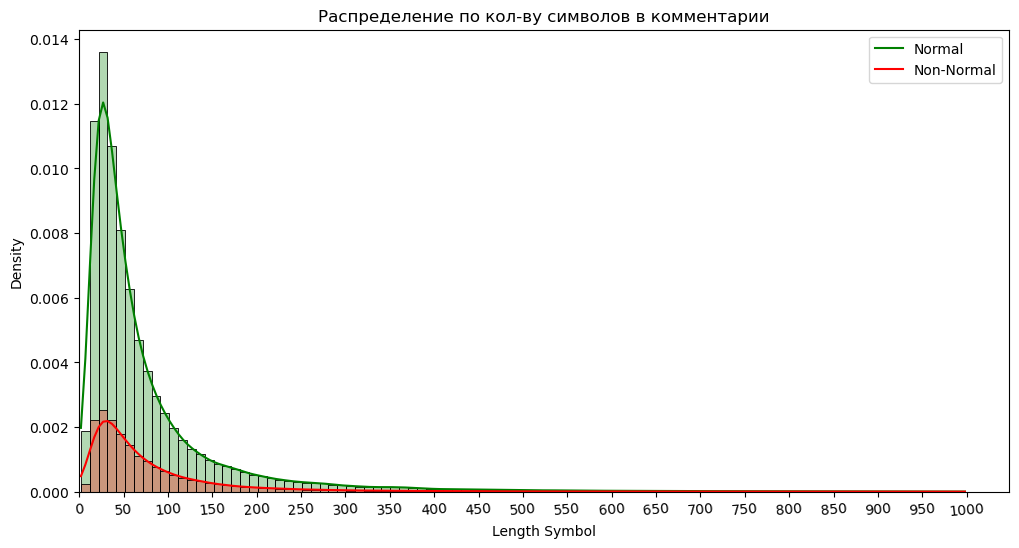

In [83]:
df['is_normal'] = (df['label'] == '__label__NORMAL')

plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='length_sym', hue='is_normal', 
             bins=100, alpha=0.3, palette={False: 'red', True: 'green'},
             stat='density', kde=True)

plt.xticks(rotation=5)
plt.locator_params(axis='x', nbins=40)
plt.xlabel('Length Symbol')
plt.title('Распределение по кол-ву символов в комментарии')
plt.legend(['Normal', 'Non-Normal'])
plt.xlim(0)
plt.show()

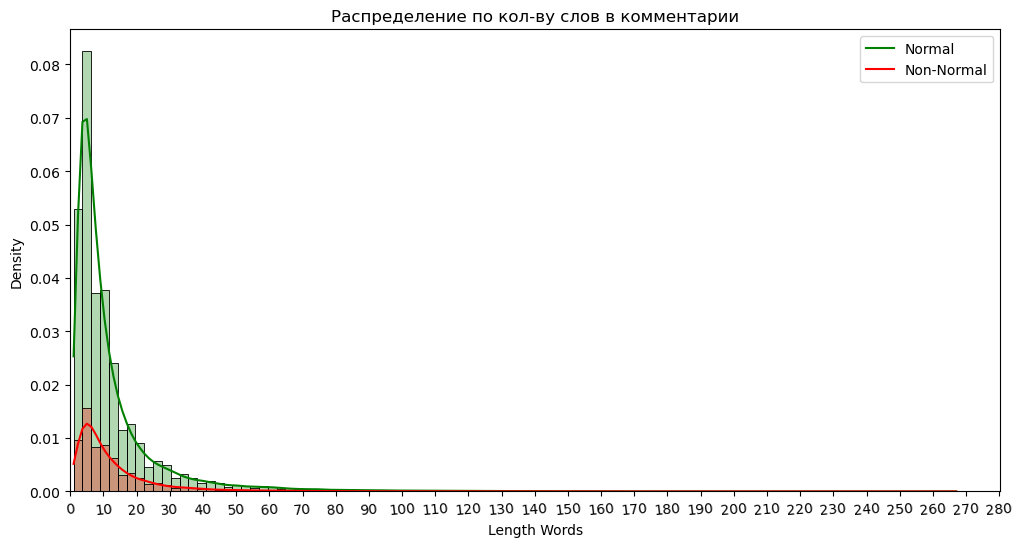

In [84]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='length_words', hue='is_normal', 
             bins=100, alpha=0.3, palette={False: 'red', True: 'green'},
             stat='density', kde=True)

plt.xticks(rotation=5)
plt.locator_params(axis='x', nbins=40)
plt.xlabel('Length Words')
plt.title('Распределение по кол-ву слов в комментарии')
plt.legend(['Normal', 'Non-Normal'])
plt.xlim(0)
plt.show()

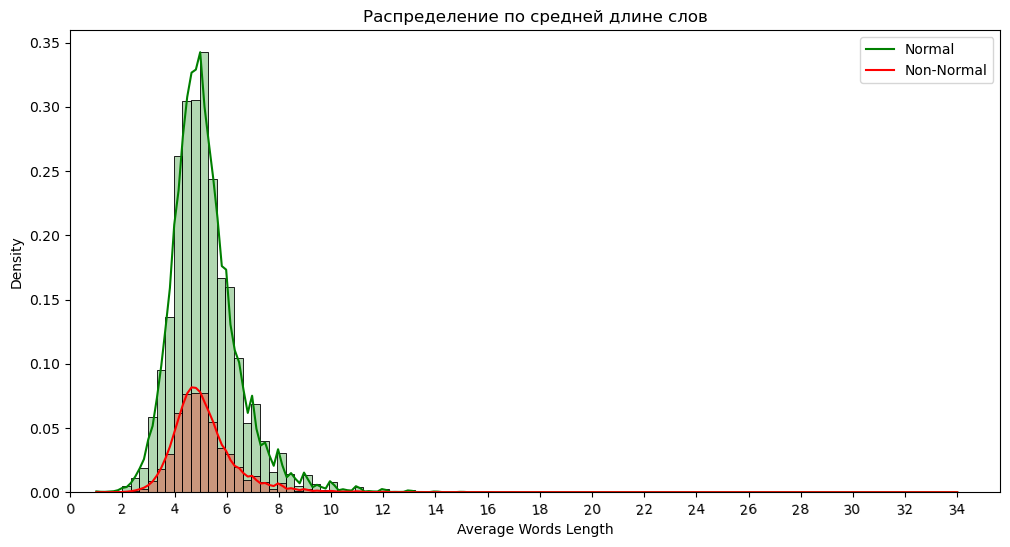

In [85]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='av_word_len', hue='is_normal', 
             bins=100, alpha=0.3, palette={False: 'red', True: 'green'},
             stat='density', kde=True)

plt.xticks(rotation=5)
plt.locator_params(axis='x', nbins=30)
plt.xlabel('Average Words Length')
plt.title('Распределение по средней длине слов')
plt.legend(['Normal', 'Non-Normal'])
plt.xlim(0)
plt.show()

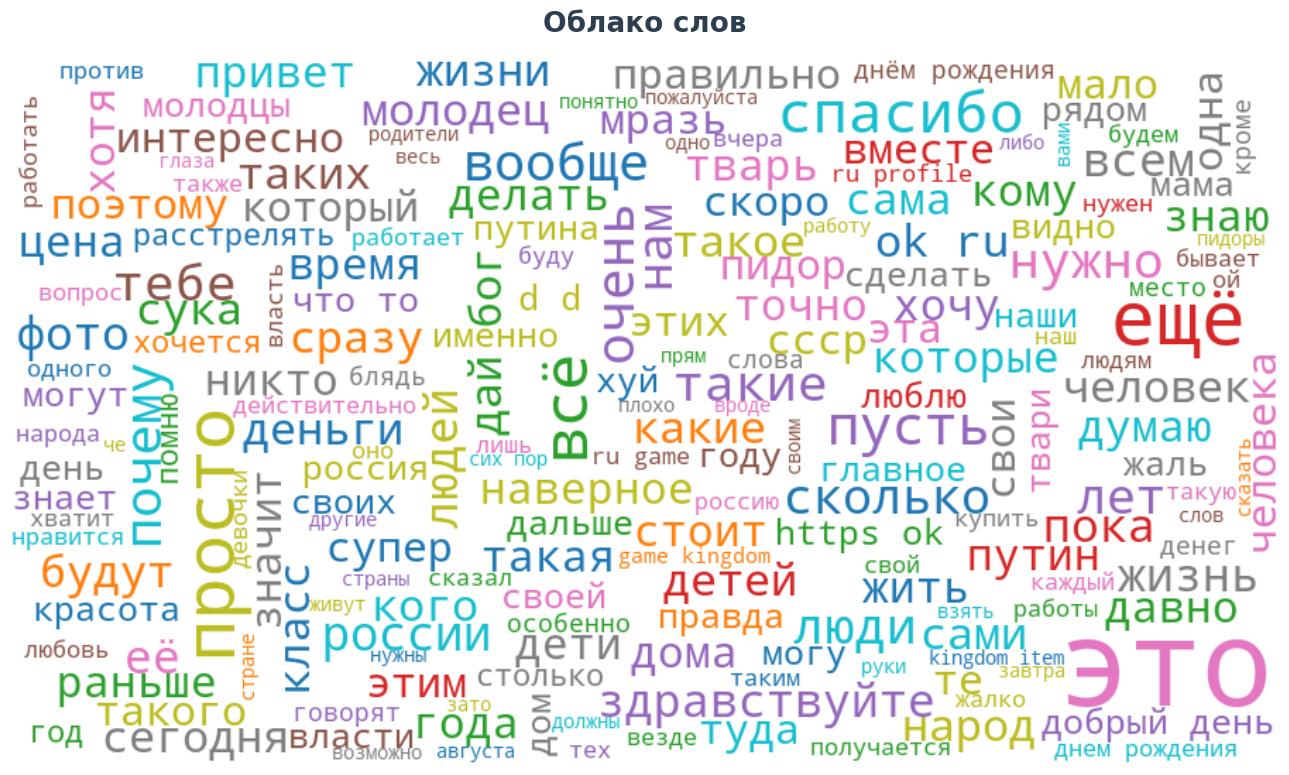

In [86]:
plt.figure(figsize=(13, 8))
word_cloud = WordCloud(
    background_color='#ffffff',
    max_font_size=85,
    width=900,
    height=500,
    colormap='tab10',
    contour_width=3,
    contour_color='#34495e',
    margin=2
).generate(" ".join(df['cleaned_comment']))

plt.imshow(word_cloud, interpolation='bilinear')
plt.axis('off')
plt.title('Облако слов', 
          fontsize=20, 
          fontweight='semibold', 
          color='#2c3e50',
          pad=20)
plt.tight_layout()
plt.show()